# Environment Setup

In [220]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Set up project path

In [221]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [222]:
project_path = '/content/drive/MyDrive/Colab Notebooks/cs-5530-assignment-2/question_2'

Constants

In [223]:
# Set a random seed to ensure responsibility
SEED = 5530

np.random.seed(SEED)

Load data into a dataframe

In [224]:
diabetes_data = pd.read_csv(project_path + '/data/diabetes.csv')

print(diabetes_data.shape)
diabetes_data.head(10)

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# **Part A) Sampling and Statistic Comparison**

Take a random sample of 25 observations from the population

In [225]:
sample_data = diabetes_data.sample(n=25, random_state=SEED)

sample_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
562,1,87,68,34,77,37.6,0.401,24,0
579,2,197,70,99,0,34.7,0.575,62,1
320,4,129,60,12,231,27.5,0.527,31,0
136,0,100,70,26,50,30.8,0.597,21,0
379,0,93,100,39,72,43.4,1.021,35,0


Compute the mean and max of the sample dataset and the population

In [226]:
# Sample
sample_mean = sample_data['Glucose'].mean()
sample_max = sample_data['Glucose'].max()

print('Sample Mean: ', sample_mean)
print('Sample Max: ', sample_max)

# Population
population_mean = diabetes_data['Glucose'].mean()
population_max = diabetes_data['Glucose'].max()

print('Population Mean: ', population_mean)
print('Population Max: ', population_max)

Sample Mean:  130.32
Sample Max:  197
Population Mean:  120.89453125
Population Max:  199


Dataframe containing all computed statistics

In [227]:
glucose_stats_df = pd.DataFrame()
glucose_stats_df['Group'] = ['Sample', 'Population']
glucose_stats_df['Mean'] = [sample_mean, population_mean]
glucose_stats_df['Max'] = [sample_max, population_max]

glucose_stats_df

,Group,Mean,Max
0,Sample,130.320000,197
1,Population,120.894531,199


Bar charts comparing mean and max glucose for sample vs population

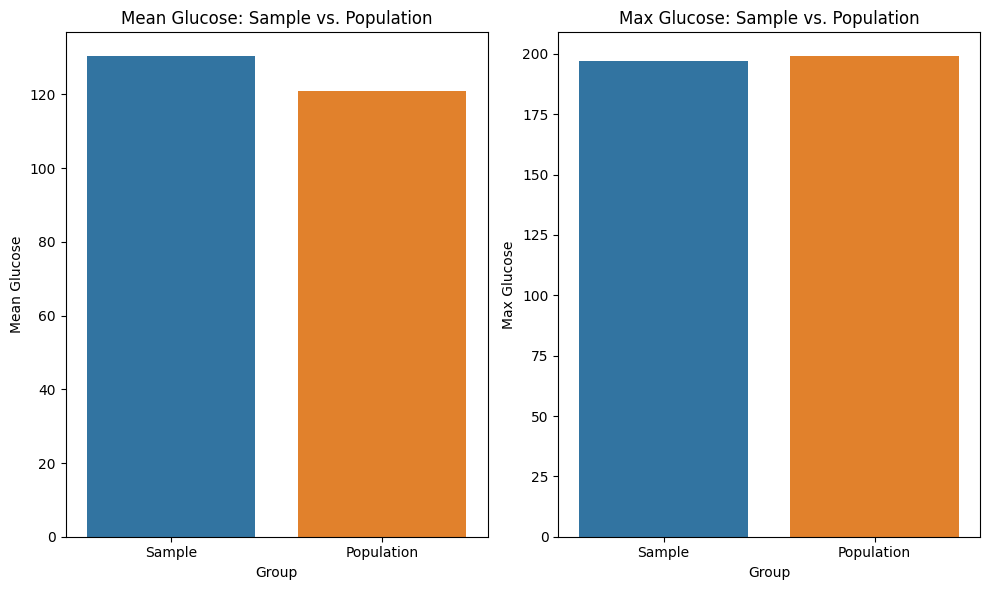

In [228]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

sns.barplot(data=glucose_stats_df, x='Group', y='Mean', hue='Group', ax=axes[0])
sns.barplot(data=glucose_stats_df, x='Group', y='Max', hue='Group', ax=axes[1])

axes[0].set_title('Mean Glucose: Sample vs. Population')
axes[0].set_ylabel('Mean Glucose')

axes[1].set_title('Max Glucose: Sample vs. Population')
axes[1].set_ylabel('Max Glucose')

plt.tight_layout()
plt.savefig(project_path + '/visualizations/part_a_glucose_stats_barcharts.png', dpi=300)
plt.show()


Mean Glucose:
* The population mean was lower than the sample mean.

Max Glucose:
* The max glucose levels were almost the same, with the population having only a slightly higher value.


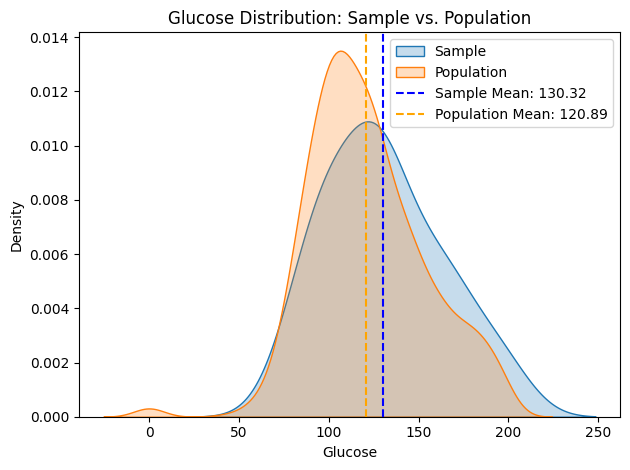

In [229]:
sns.kdeplot(data=sample_data, x='Glucose', fill=True, label='Sample')
sns.kdeplot(data=diabetes_data, x='Glucose', fill=True, label='Population')

plt.title('Glucose Distribution: Sample vs. Population')
plt.axvline(sample_mean, color='b', linestyle='--', label=f'Sample Mean: {sample_mean:.2f}')
plt.axvline(population_mean, color='orange', linestyle='--', label=f'Population Mean: {population_mean:.2f}')
plt.legend()

plt.tight_layout()
plt.savefig(project_path + '/visualizations/part_a_glucose_distribution.png', dpi=300)
plt.show()

This density plot shows the distributions of glucose values for both the sample and population. It can be observed that the sample distribution has a higher proportion of observations at higher glucose levels, which explains why the sample has a higher mean.

# **Part B) 98th Percentile**

Find the 98th Percentile of BMI of the Sample

In [230]:
sample_98 = sample_data['BMI'].quantile(0.98)
sample_98

np.float64(49.324)

Find the 98th Percentile of BMI of the Population

In [231]:
pop_98 = diabetes_data['BMI'].quantile(0.98)
pop_98

np.float64(47.52599999999996)

Dataframe containing BMI statistics

In [232]:
bmi_stats_df = pd.DataFrame()
bmi_stats_df['Group'] = ['Sample', 'Population']
bmi_stats_df['98_Percentile'] = [sample_98, pop_98]

bmi_stats_df

,Group,98_Percentile
0,Sample,49.324
1,Population,47.526


Get a combined dataset of both the sample and population BMIs to compare the distribution in a chart

In [233]:
# Combine BMI Columns from both Sample and Population
combined_bmi = pd.concat([sample_data['BMI'], diabetes_data['BMI']], axis=1, ignore_index=True)
combined_bmi.rename(columns={0:'Sample', 1:'Population'}, inplace=True)

# Pivot into long form
combined_bmi = combined_bmi.melt(var_name='Group', value_name='BMI').dropna().reset_index()

combined_bmi

,index,Group,BMI
0,0,Sample,37.6
1,1,Sample,34.7
2,2,Sample,27.5
3,3,Sample,30.8
4,4,Sample,43.4
...,...,...,...
788,1531,Population,32.9
789,1532,Population,36.8
790,1533,Population,26.2
791,1534,Population,30.1


Barchart comparing the 98th percentiles of BMIs of the sample and population

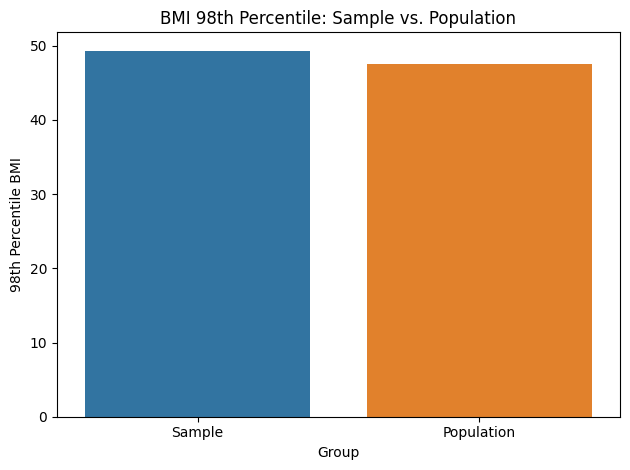

In [234]:
sns.barplot(data=bmi_stats_df, x='Group', y='98_Percentile', hue='Group')

plt.title('BMI 98th Percentile: Sample vs. Population')
plt.ylabel('98th Percentile BMI')

plt.tight_layout()
plt.savefig(project_path + '/visualizations/part_b_bmi_barchart.png', dpi=300)
plt.show()

Boxplots Comparing Percentiles

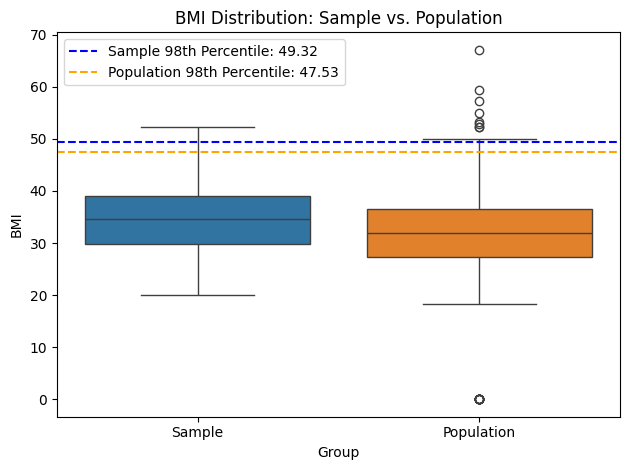

In [235]:
sns.boxplot(data=combined_bmi, x='Group', y='BMI', hue='Group')

plt.title('BMI Distribution: Sample vs. Population')
plt.axhline(sample_98, color='b', linestyle='--', label=f'Sample 98th Percentile: {sample_98:.2f}')
plt.axhline(pop_98, color='orange', linestyle='--', label=f'Population 98th Percentile: {pop_98:.2f}')
plt.legend()

plt.tight_layout()
plt.savefig(project_path + '/visualizations/part_b_bmi_boxplot.png', dpi=300)
plt.show()

The barchart and boxplot show that the sample had a slightly higher 98th percentile BMI than the population. The boxplot shows that the population had a higher max BMI value and many outliers (which were above the sample data's range), however its 98th percentile was still lower.

# **Part C) Bootstrap**

Collect the mean, standard deviation, and 98th percentile of BloodPressure for each bootstrap sample.

Take 500 samples, each with 150 observations.
* Samples taken directly from the population as directed in the assignment instructions.
* Wasn't certain if bootstrap samples should be taken from an original sample of 150 observations, as it wasn't specified.

In [236]:
bootstraps = pd.DataFrame()

bootstrap_means = []
bootstrap_stds = []
bootstrap_percentiles = []

for i in range(500):
  bootstrap_sample = diabetes_data.sample(n=150, replace=True)
  bootstrap_means.append(bootstrap_sample['BloodPressure'].mean())
  bootstrap_stds.append(bootstrap_sample['BloodPressure'].std())
  bootstrap_percentiles.append(bootstrap_sample['BloodPressure'].quantile(0.98))

bootstraps['Mean'] = bootstrap_means
bootstraps['Standard_Deviation'] = bootstrap_stds
bootstraps['98_Percentile'] = bootstrap_percentiles

bootstraps.head()


,Mean,Standard_Deviation,98_Percentile
0,68.820000,16.364584,94.04
1,69.986667,17.092322,92.12
2,70.540000,15.466192,96.00
3,69.473333,18.017775,94.04
4,68.266667,19.556721,92.08


Compute the average mean, standard deviation, and 98th percentile from the bootstraps

In [237]:
bstrap_mean_bp = bootstraps['Mean'].mean()
bstrap_std_bp = bootstraps['Standard_Deviation'].mean()
bstrap_98_pct_bp = bootstraps['98_Percentile'].mean()

Compute the mean, standard deviation, and 98th percentile of BloodPressure for the population

In [238]:
pop_mean_bp = diabetes_data['BloodPressure'].mean()
pop_std_bp = diabetes_data['BloodPressure'].std()
pop_98_pct_bp = diabetes_data['BloodPressure'].quantile(0.98)

Combine these values into a dataframe

In [239]:
bp_stats_df = pd.DataFrame()
bp_stats_df['Group'] = ['Bootstrap', 'Population']
bp_stats_df['Mean'] = [bstrap_mean_bp, pop_mean_bp]
bp_stats_df['Standard_Deviation'] = [bstrap_std_bp, pop_std_bp]
bp_stats_df['98_Percentile'] = [bstrap_98_pct_bp, pop_98_pct_bp]

bp_stats_df

,Group,Mean,Standard_Deviation,98_Percentile
0,Bootstrap,69.163213,19.154861,98.19148
1,Population,69.105469,19.355807,99.32000


Density plots showing the bootstrap distributions for each statistic
* Vertical lines representing avg of bootstrap statistic and population statistic included for comparison

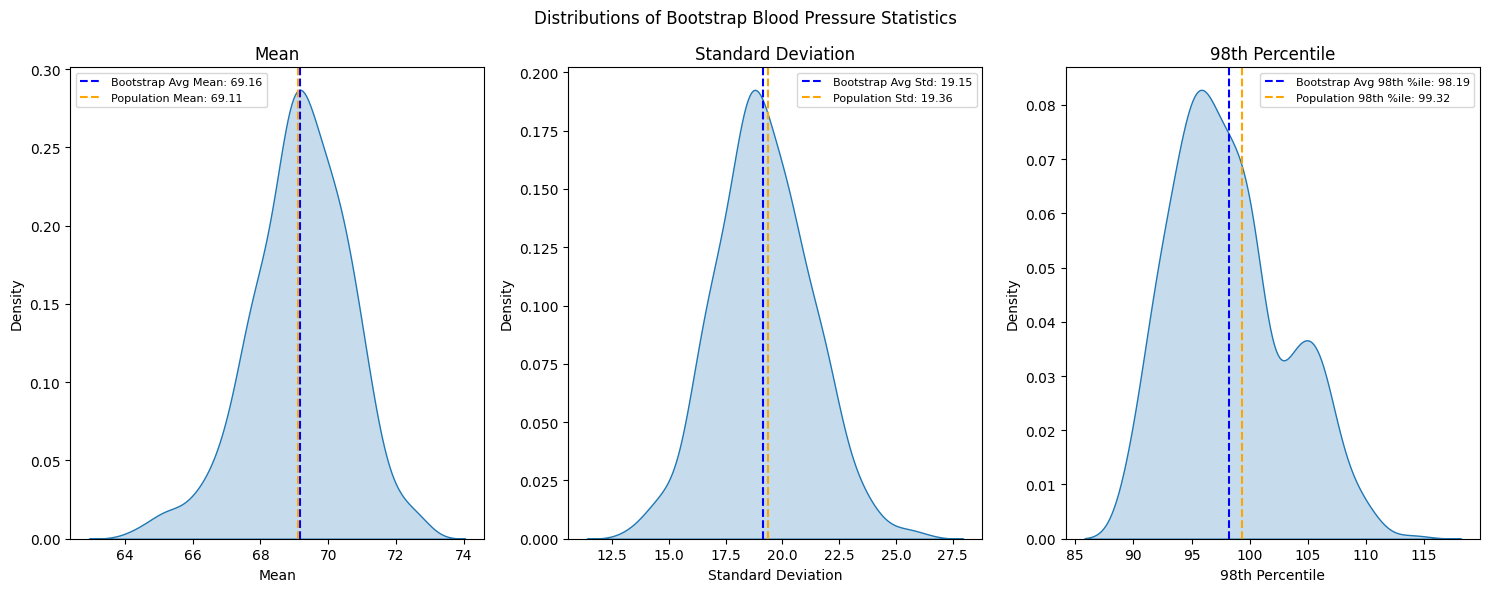

In [240]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

sns.kdeplot(data=bootstraps, x='Mean', fill=True, ax=axes[0])
sns.kdeplot(data=bootstraps, x='Standard_Deviation', fill=True, ax=axes[1])
sns.kdeplot(data=bootstraps, x='98_Percentile', fill=True, ax=axes[2])

fig.suptitle('Distributions of Bootstrap Blood Pressure Statistics')

axes[0].set_title('Mean')
axes[0].axvline(bstrap_mean_bp, color='b', linestyle='--', label=f'Bootstrap Avg Mean: {bstrap_mean_bp:.2f}')
axes[0].axvline(pop_mean_bp, color='orange', linestyle='--', label=f'Population Mean: {pop_mean_bp:.2f}')
axes[0].legend(fontsize=8)

axes[1].set_title('Standard Deviation')
axes[1].set_xlabel('Standard Deviation')
axes[1].axvline(bstrap_std_bp, color='b', linestyle='--', label=f'Bootstrap Avg Std: {bstrap_std_bp:.2f}')
axes[1].axvline(pop_std_bp, color='orange', linestyle='--', label=f'Population Std: {pop_std_bp:.2f}')
axes[1].legend(fontsize=8)

axes[2].set_title('98th Percentile')
axes[2].set_xlabel('98th Percentile')
axes[2].axvline(bstrap_98_pct_bp, color='b', linestyle='--', label=f'Bootstrap Avg 98th %ile: {bstrap_98_pct_bp:.2f}')
axes[2].axvline(pop_98_pct_bp, color='orange', linestyle='--', label=f'Population 98th %ile: {pop_98_pct_bp:.2f}')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(project_path + '/visualizations/part_c_bootstrap_distributions.png', dpi=300)
plt.show()


* The distributions of the bootstrap statistics mostly follow a normal/bell curve
* The mean of the statistics of interest for the bootstrap are very close to the actual population statistics.
   * The blood pressure mean for the bootstrap only differed by 0.05 units from the population. This is a very negligible difference.
   * The average standard deviation for the bootstrap is slightly less than the population, but is still within one unit.
   * The difference between the 98th percentiles is the largest gap. This makes sense since very high or low percentiles may not be sampled as often. However, the difference is still very small.
* The closeness of the bootstrap and population values shows how good of an estimate the bootstrap provides. It can be a very useful and reliable tool for estimating certain sampling statistics.
   * The large sample size and number of bootstrap samples also allowed us to get these results.

Bar charts comparing bootstrap and population statistics

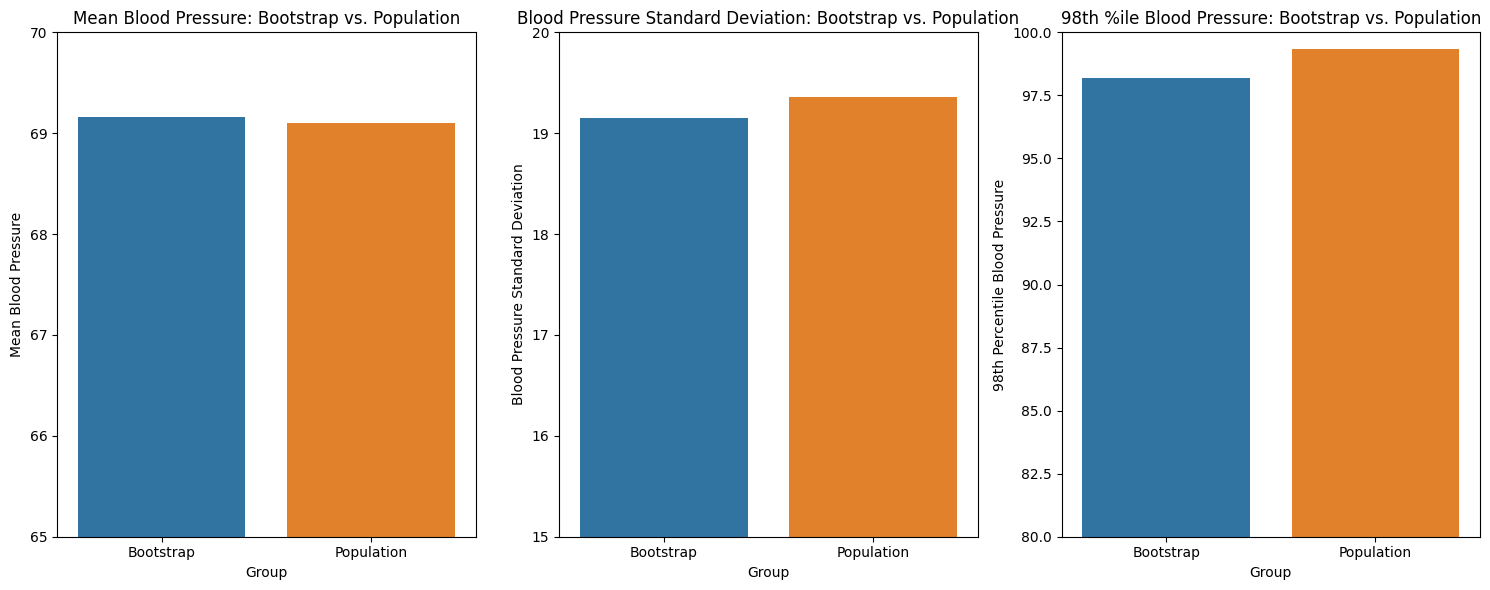

In [241]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

sns.barplot(data=bp_stats_df, x='Group', y='Mean', hue='Group', ax=axes[0])
sns.barplot(data=bp_stats_df, x='Group', y='Standard_Deviation', hue='Group', ax=axes[1])
sns.barplot(data=bp_stats_df, x='Group', y='98_Percentile', hue='Group', ax=axes[2])

axes[0].set_title('Mean Blood Pressure: Bootstrap vs. Population')
axes[0].set_ylabel('Mean Blood Pressure')
axes[0].set_ylim(65,70)

axes[1].set_title('Blood Pressure Standard Deviation: Bootstrap vs. Population')
axes[1].set_ylabel('Blood Pressure Standard Deviation')
axes[1].set_ylim(15,20)

axes[2].set_title('98th %ile Blood Pressure: Bootstrap vs. Population')
axes[2].set_ylabel('98th Percentile Blood Pressure')
axes[2].set_ylim(80,100)

plt.tight_layout()
plt.savefig(project_path + '/visualizations/part_c_blood_pressure_barcharts.png', dpi=300)
plt.show()


These additional bar charts were made to directly compare the values of the population statistics and the averages from the bootstrap distributions.
* They reinforce the results from the density plots.
* The range on the Y-axis was condensed to better compare the differences in values.
* The average bootstrap statistics were very close in value to the population.
* Mean was the most similar, followed by standard deviation, then the 98th percentile.